# Atelier TensorFlow / Keras — Prédiction de la consommation énergétique

**Contexte.** Des bâtiments sont équipés de capteurs. Pour chaque observation on connaît la température, l'humidité et le nombre d'occupants. On veut construire un **réseau de neurones** qui prédit la **consommation énergétique** à partir de ces trois caractéristiques.

C'est un problème de **régression** : la cible (consommation) est un nombre continu.

## Partie 0 — Mise en place de l'environnement

On importe les trois librairies demandées :
- **numpy** : calcul numérique et génération des données aléatoires,
- **tensorflow / keras** : construction et entraînement du réseau de neurones,
- **matplotlib** : visualisation.

> Si TensorFlow n'est pas installé : `pip install tensorflow`

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

print("TensorFlow version :", tf.__version__)

I0000 00:00:1787426848.904043     558 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787426849.035753     558 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787426850.946708     558 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version : 2.21.0


On **fixe les graines aléatoires** (numpy et TensorFlow). Cela rend l'exécution **reproductible** : on obtiendra les mêmes données générées et le même entraînement à chaque relance.

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

## Partie 1 — Génération du dataset

On simule **1000 observations**. Pour chaque variable on choisit une loi de probabilité adaptée :

| Variable | Loi | Paramètres |
|---|---|---|
| `temperature` | Normale (gaussienne) | moyenne = 25 °C, écart-type = 4 °C |
| `humidite` | Uniforme | entre 30 % et 80 % |
| `occupants` | Entiers uniformes | de 1 à 49 inclus |

- **loi normale** : les valeurs se concentrent autour de la moyenne (25) et deviennent rares en s'en éloignant.
- **loi uniforme** : toutes les valeurs entre 30 et 80 ont la même chance de sortir.

In [3]:
n = 1000

temperature = np.random.normal(loc=25, scale=4, size=n)      # moyenne 25, ecart-type 4
humidite    = np.random.uniform(low=30, high=80, size=n)     # uniforme entre 30 et 80
occupants   = np.random.randint(low=1, high=50, size=n)      # entiers 1..49 (high exclu)

print("temperature :", temperature[:5])
print("humidite    :", humidite[:5])
print("occupants   :", occupants[:5])

temperature : [26.98685661 24.4469428  27.59075415 31.09211943 24.0633865 ]
humidite    : [38.37412911 35.22839202 61.82151248 65.32378632 31.57930724]
occupants   : [ 8 43 20 33 26]


### Construction de la cible `consommation`

On applique la formule "physique" donnée par l'énoncé :

$$ \text{consommation} = 50 + 5\times\text{temp} + 1.5\times\text{humidite} + 4\times\text{occupants} + \text{bruit} $$

- **50** = consommation de base (0 °C, 0 % humidité, pièce vide),
- **+5** par degré, **+1.5** par % d'humidité, **+4** par occupant,
- le **bruit** (loi normale de moyenne 0, écart-type 10) simule les imprévus : dans la vraie vie aucune formule n'est parfaite. C'est justement ce que le réseau devra apprendre à approcher **sans** connaître la formule.

In [4]:
bruit = np.random.normal(loc=0, scale=10, size=n)

consommation = 50 + 5*temperature + 1.5*humidite + 4*occupants + bruit

print("consommation :", consommation[:5])

consommation : [281.62608854 406.67868707 348.62841819 433.63621523 318.9414931 ]


### Matrice des caractéristiques `X` et cible `y`

- `X` regroupe les 3 variables explicatives → forme **(1000, 3)**.
- `y` contient la consommation → forme **(1000,)**.

On convertit en **float32** : c'est le format optimisé pour les calculs sur GPU/CPU dans TensorFlow.

In [5]:
X = np.column_stack([temperature, humidite, occupants]).astype("float32")
y = consommation.astype("float32")

print("Forme de X :", X.shape)   # (1000, 3)
print("Forme de y :", y.shape)   # (1000,)
print("\n5 premieres lignes de X :\n", X[:5])

Forme de X : (1000, 3)
Forme de y : (1000,)

5 premieres lignes de X :
 [[26.986856 38.37413   8.      ]
 [24.446943 35.228394 43.      ]
 [27.590754 61.821514 20.      ]
 [31.09212  65.323784 33.      ]
 [24.063387 31.579308 26.      ]]


## Partie 2 — Découpage Train / Test

On sépare les données en deux :
- **train (80 %)** : sert à *entraîner* le modèle,
- **test (20 %)** : sert à *évaluer* le modèle sur des données jamais vues.

`random_state=42` garantit la **reproductibilité** du découpage.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train :", X_train.shape, y_train.shape)
print("Test  :", X_test.shape,  y_test.shape)

Train : (800, 3) (800,)
Test  : (200, 3) (200,)


## Partie 3 — Création du modèle

On empile 3 couches denses (**Sequential** = les couches s'enchaînent l'une après l'autre) :

1. **16 neurones**, activation **ReLU**,
2. **8 neurones**, activation **ReLU**,
3. **1 neurone** (sortie) — pas d'activation : on veut une valeur continue (régression).

- **neurone** : une petite unité qui combine ses entrées et produit une sortie.
- **ReLU** (`Rectified Linear Unit`) : fonction d'activation qui renvoie `max(0, x)`. Elle introduit de la **non-linéarité**, ce qui permet au réseau d'apprendre des relations complexes.
- `input_shape=(3,)` indique que chaque exemple a **3 caractéristiques**.

In [7]:
model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(3,)),   # couche 1
    layers.Dense(8,  activation="relu"),                     # couche 2
    layers.Dense(1)                                          # couche 3 : sortie
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Résumé de l'architecture

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

## Partie 4 — Compilation du modèle

Compiler = préciser **comment le modèle va apprendre** :
- **optimizer = `adam`** : l'algorithme qui ajuste les poids du réseau à chaque étape (Adam est un choix robuste et standard).
- **loss = `mse`** (Mean Squared Error, erreur quadratique moyenne) : la fonction que le modèle cherche à **minimiser**. Elle pénalise fortement les grosses erreurs.
- **metric = `mae`** (Mean Absolute Error, erreur absolue moyenne) : plus lisible pour nous — c'est l'écart moyen, en unités de consommation, entre prédiction et réalité.

In [9]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

## Partie 5 — Entraînement du modèle

On entraîne avec :
- `validation_split=0.2` : 20 % du train sert de **validation** (pour surveiller le sur-apprentissage),
- `epochs=50` : le modèle voit **50 fois** l'ensemble des données,
- `batch_size=16` : les poids sont mis à jour toutes les **16 observations**.

L'objet `history` mémorise l'évolution de l'erreur au fil des époques.

In [10]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50



 1/40 ━━━━━━━━━━━━━━━━━━━━ 30s 794ms/step - loss: 140239.8594 - mae: 368.5356


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 137189.5781 - mae: 364.7021 - val_loss: 130665.1641 - val_mae: 356.6241


Epoch 2/50



 1/40 ━━━━━━━━━━━━━━━━━━━━ 12s 333ms/step - loss: 130755.7500 - mae: 356.0781

...


 1/40 ━━━━━━━━━━━━━━━━━━━━ 6s 161ms/step - loss: 92.9697 - mae: 7.5585


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 145.4438 - mae: 9.6208 - val_loss: 129.2085 - val_mae: 9.2013


Epoch 50/50



 1/40 ━━━━━━━━━━━━━━━━━━━━ 6s 163ms/step - loss: 92.0138 - mae: 7.5533


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 144.5504 - mae: 9.5985 - val_loss: 128.4489 - val_mae: 9.1658


### Examiner le contenu de `history`

`history.history` est un dictionnaire contenant l'erreur (`loss`, `mae`) sur le train **et** sur la validation (`val_loss`, `val_mae`), une valeur par époque.

In [11]:
print("Cles disponibles :", list(history.history.keys()))
print("\nloss (train) - 5 premieres epoques :", history.history["loss"][:5])
print("val_loss (validation) - 5 premieres :", history.history["val_loss"][:5])

Cles disponibles : ['loss', 'mae', 'val_loss', 'val_mae']

loss (train) - 5 premieres epoques : [137189.578125, 125139.9765625, 106429.578125, 81574.828125, 52151.18359375]
val_loss (validation) - 5 premieres : [130665.1640625, 115571.7890625, 94215.890625, 66631.6171875, 37167.5703125]


### Visualiser l'apprentissage

On trace l'erreur d'entraînement et de validation en fonction des époques.

**Interprétation attendue :** les deux courbes doivent **descendre** puis se stabiliser. Si la courbe de validation remonte alors que celle du train continue de descendre → **sur-apprentissage** (overfitting).

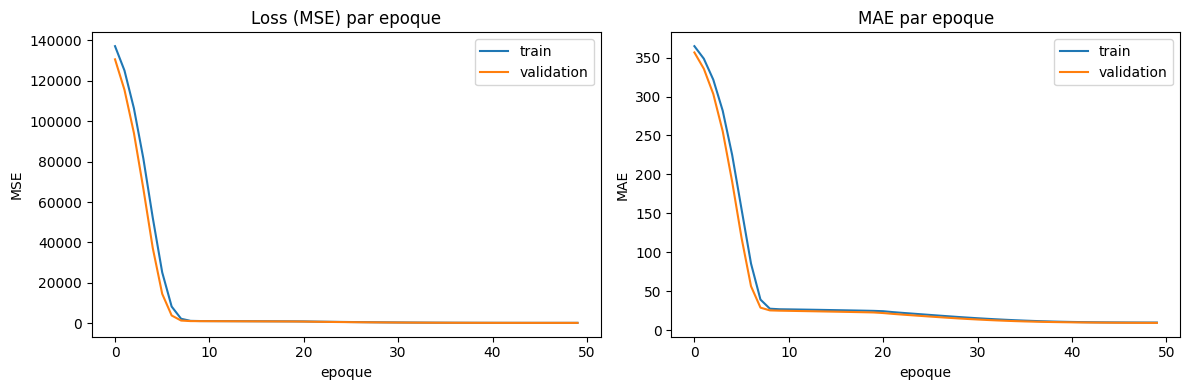

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="validation")
axes[0].set_title("Loss (MSE) par epoque")
axes[0].set_xlabel("epoque"); axes[0].set_ylabel("MSE"); axes[0].legend()

axes[1].plot(history.history["mae"], label="train")
axes[1].plot(history.history["val_mae"], label="validation")
axes[1].set_title("MAE par epoque")
axes[1].set_xlabel("epoque"); axes[1].set_ylabel("MAE"); axes[1].legend()

plt.tight_layout()
plt.show()

**Lecture du graphique :** l'erreur chute vite au début (le modèle apprend la tendance générale) puis se stabilise. Les courbes train et validation restent proches → le modèle **généralise bien**, il n'y a pas de sur-apprentissage marqué.

## Partie 6 — Évaluation

`model.evaluate` renvoie la **perte (MSE)** et la **métrique (MAE)** sur les données de **test** (jamais vues à l'entraînement).

In [13]:
loss_test, mae_test = model.evaluate(X_test, y_test, verbose=0)

print(f"MSE sur le test : {loss_test:.2f}")
print(f"MAE sur le test : {mae_test:.2f}")

MSE sur le test : 179.99
MAE sur le test : 10.78


**Interprétation :** la MAE s'exprime dans l'unité de la consommation. Une MAE d'environ 8 à 12 signifie qu'en moyenne le modèle se trompe de ~8 à 12 unités sur la consommation. Or on a ajouté un bruit d'écart-type 10 dans la formule : le modèle **ne peut pas** faire mieux que ce bruit irréductible. Être proche de 10 est donc un **excellent** résultat.

## Partie 7 — Prédiction

On prédit la consommation sur le jeu de test, puis on **compare aux vraies valeurs**.

In [14]:
y_pred = model.predict(X_test, verbose=0).flatten()

# Comparaison des 10 premieres
for reel, pred in zip(y_test[:10], y_pred[:10]):
    print(f"reel = {reel:7.2f}   |   predit = {pred:7.2f}   |   ecart = {reel-pred:6.2f}")

reel =  334.86   |   predit =  337.96   |   ecart =  -3.10
reel =  383.14   |   predit =  395.36   |   ecart = -12.22
reel =  377.82   |   predit =  365.92   |   ecart =  11.90
reel =  292.87   |   predit =  287.26   |   ecart =   5.61
reel =  396.37   |   predit =  396.46   |   ecart =  -0.10
reel =  367.03   |   predit =  367.54   |   ecart =  -0.51
reel =  309.89   |   predit =  312.12   |   ecart =  -2.23
reel =  293.61   |   predit =  284.44   |   ecart =   9.17
reel =  360.86   |   predit =  367.30   |   ecart =  -6.44
reel =  414.29   |   predit =  416.57   |   ecart =  -2.28


### Visualiser : prédictions vs valeurs réelles

On place chaque point (valeur réelle en x, valeur prédite en y). **Si le modèle était parfait**, tous les points seraient sur la **diagonale y = x** (rouge).

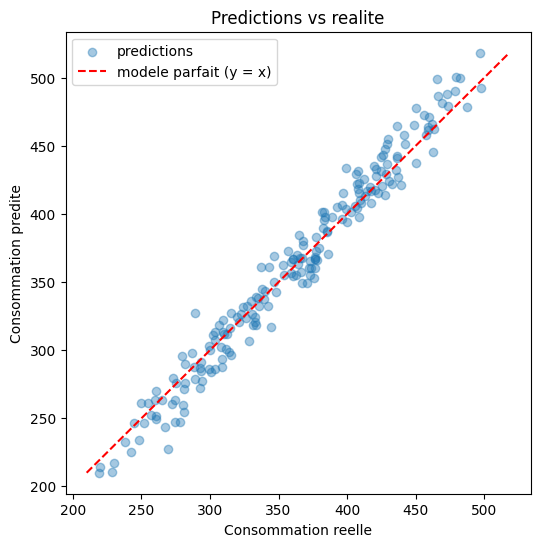

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4, label="predictions")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="modele parfait (y = x)")
plt.xlabel("Consommation reelle")
plt.ylabel("Consommation predite")
plt.title("Predictions vs realite")
plt.legend()
plt.show()

**Lecture :** les points sont **serrés autour de la diagonale** → les prédictions suivent fidèlement les valeurs réelles. La légère dispersion correspond au bruit aléatoire injecté dans les données.

## Partie 8 — Sauvegarde du modèle

On sauvegarde le modèle au format Keras (`.keras`). Le notebook s'exécutant depuis `notebooks/`, on remonte d'un niveau (`..`) pour écrire dans `models/`.

In [16]:
import os
os.makedirs("../models", exist_ok=True)
chemin_modele = "../models/modele_consommation.keras"

model.save(chemin_modele)
print("Modele sauvegarde dans :", chemin_modele)

Modele sauvegarde dans : ../models/modele_consommation.keras


## Partie 9 — Chargement du modèle

On recharge le modèle sauvegardé, on affiche son résumé, puis on refait une prédiction pour vérifier qu'il fonctionne à l'identique.

In [17]:
modele_charge = keras.models.load_model(chemin_modele)
modele_charge.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 629 (2.46 KB)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 420 (1.64 KB)

In [18]:
# Nouvelle prediction avec le modele recharge
pred_test = modele_charge.predict(X_test[:5], verbose=0).flatten()
print("Predictions du modele recharge :", pred_test)

Predictions du modele recharge :

 [337.96063 395.36313 365.91818 287.26135 396.46353]


## Partie 10 — Fonction d'inférence

On encapsule la prédiction dans une fonction réutilisable `predire_consommation(temperature, humidite, occupants)` qui renvoie la consommation estimée.

Le modèle attend un tableau de forme `(n, 3)` en `float32` → on construit ce tableau à partir des 3 arguments.

In [19]:
def predire_consommation(temperature, humidite, occupants, modele=modele_charge):
    """Predit la consommation energetique pour une observation."""
    x = np.array([[temperature, humidite, occupants]], dtype="float32")
    prediction = modele.predict(x, verbose=0)
    return float(prediction[0][0])

### Test de la fonction

Vérification "à la main" : avec temp=25, humidite=55, occupants=10, la formule donne
50 + 5·25 + 1.5·55 + 4·10 ≈ **297.5** (au bruit près). La prédiction doit être proche.

In [20]:
estimation = predire_consommation(temperature=25, humidite=55, occupants=10)
print(f"Consommation estimee : {estimation:.2f}")
print("Valeur theorique (sans bruit) : 297.50")

Consommation estimee : 296.82
Valeur theorique (sans bruit) : 297.50


## Partie 11 — Bonus : importance des variables (analyse de sensibilité)

Le modèle est une "boîte noire". Une fonctionnalité utile : mesurer **l'influence de chaque variable** sur la prédiction. On part d'une observation moyenne, on fait varier **une seule** variable à la fois et on observe de combien la consommation prédite change.

On retrouve alors l'ordre d'importance cohérent avec la formule (+5/°C, +4/occupant, +1.5/%humidité).

In [21]:
base = {"temperature": 25, "humidite": 55, "occupants": 10}
ref = predire_consommation(**base)
print(f"Consommation de reference : {ref:.2f}\n")

for variable, delta in [("temperature", 1), ("humidite", 1), ("occupants", 1)]:
    modifie = dict(base)
    modifie[variable] += delta
    impact = predire_consommation(**modifie) - ref
    print(f"+1 sur '{variable}' -> variation de consommation : {impact:+.2f}")

Consommation de reference : 296.82



+1 sur 'temperature' -> variation de consommation : +6.08
+1 sur 'humidite' -> variation de consommation : +1.77


+1 sur 'occupants' -> variation de consommation : +4.11


**Conclusion.** L'impact estimé par le réseau (~+5 pour la température, ~+4 par occupant, ~+1.5 par % d'humidité) reflète bien la formule de génération. Le modèle a donc **appris la structure sous-jacente** des données sans qu'on la lui ait donnée.